# 🚢 Titanic Decision Tree Classifier
Manual implementation of a Decision Tree Classifier from scratch to predict passenger survival on the Titanic.

### 1. Import Libraries
Import libraries and configure custom visualization styles.

In [90]:
import pandas as pd
import random
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import ListedColormap

# Menentukan seed acak untuk menjamin reproduksibilitas
random.seed(42)
np.random.seed(42)

# Mengatur tema visualisasi 
sns.set_theme(style="whitegrid", rc={
    "grid.color": "#f1f5f9",
    "axes.edgecolor": "#cbd5e1",
    "axes.linewidth": 1.0
})
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 11

# Palette warna (Slate Gray & Steel Blue)
warna_tema = ["#94a3b8", "#3182ce"]

### 2. Load Dataset
Load the dataset using Pandas.

In [91]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 3. Data Visualization
Explore the survival distribution across the dataset.

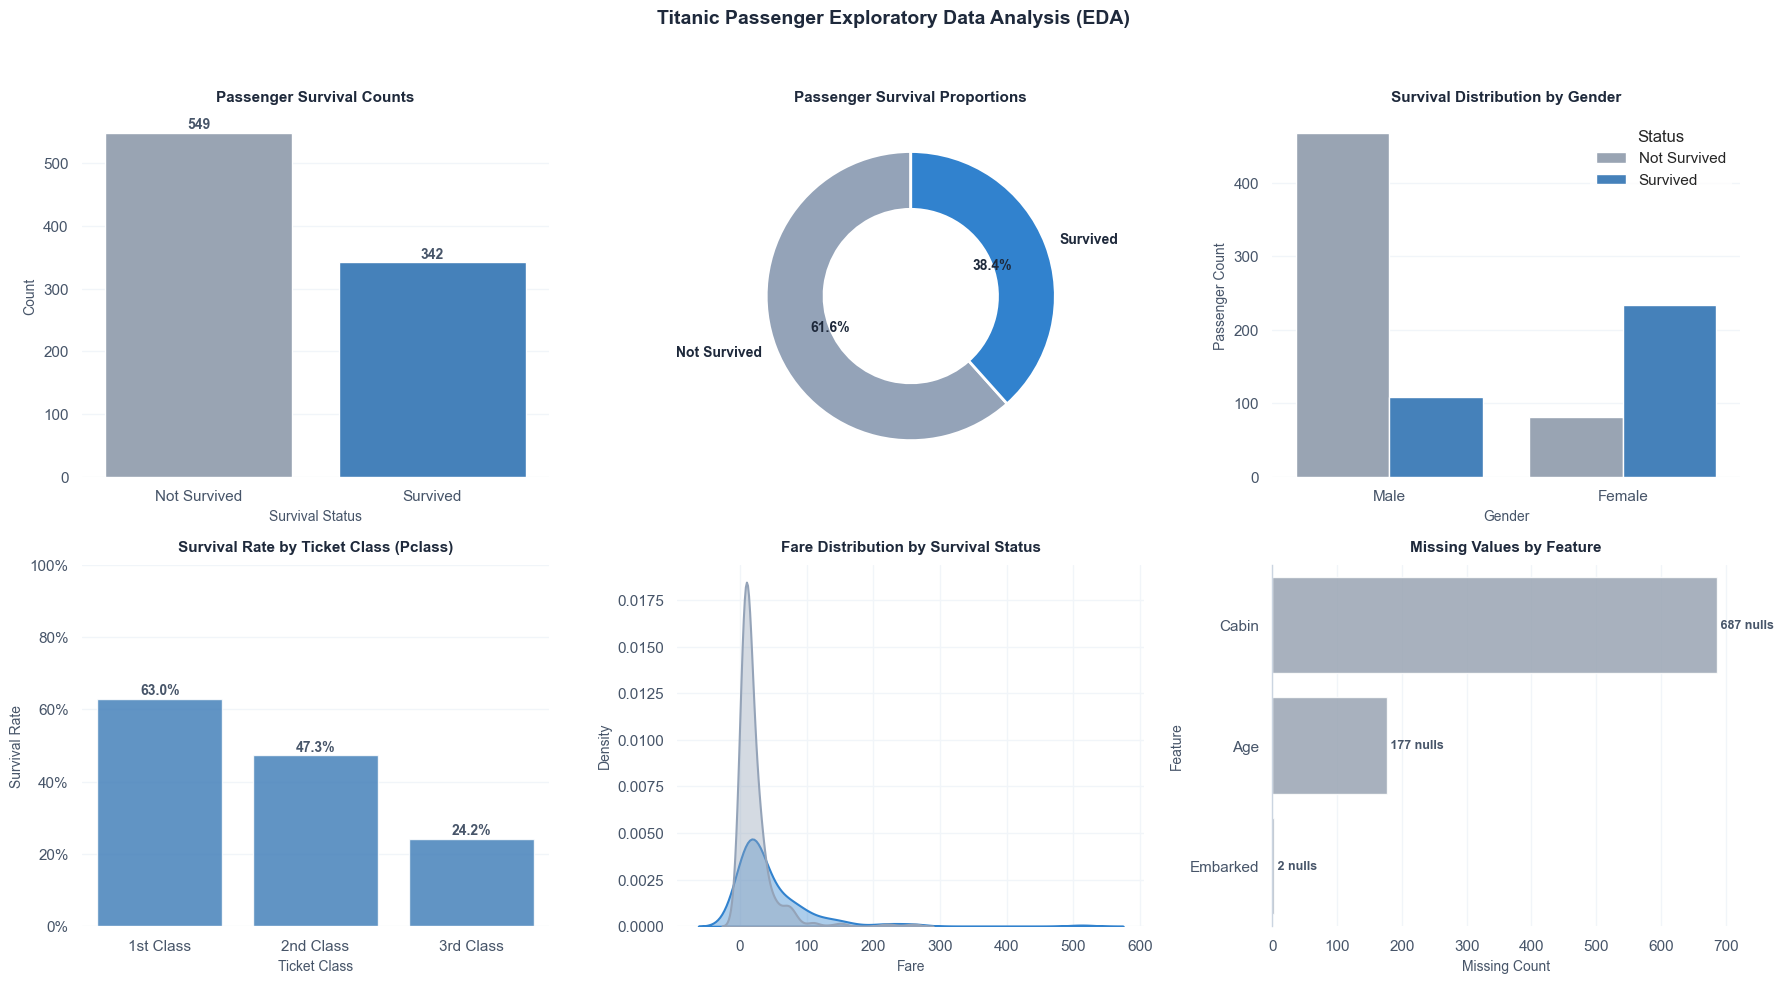

In [92]:
# 1. Prepare Data
df_visual = df.copy()
df_visual["Status"] = df_visual["Survived"].map({0: "Not Survived", 1: "Survived"})
df_visual["Sex"] = df_visual["Sex"].map({0: "Male", 1: "Female", "male": "Male", "female": "Female"})

# Load original data strictly for missing values plotting to avoid cell state issues
df_orig = pd.read_csv("train.csv")

fig, ax = plt.subplots(2, 3, figsize=(18, 10))

def clean_chart(axis, title, xlabel, ylabel, despine_opts=dict(left=True, bottom=True)):
    axis.set_title(title, fontsize=11, fontweight="bold", color="#1e293b", pad=10)
    axis.set_xlabel(xlabel, fontsize=10, color="#475569")
    axis.set_ylabel(ylabel, fontsize=10, color="#475569")
    axis.tick_params(colors="#475569")
    sns.despine(ax=axis, **despine_opts)

# --- BARIS 1 ---

# Subplot 1: Passenger Survival Counts
sns.countplot(data=df_visual, x="Status", hue="Status", legend=False, palette=warna_tema, ax=ax[0, 0])
clean_chart(ax[0, 0], "Passenger Survival Counts", "Survival Status", "Count")
for p in ax[0, 0].patches:
    ax[0, 0].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha="center", va="center", xytext=(0, 6), textcoords="offset points", fontsize=10, fontweight="bold", color="#475569")

# Subplot 2: Donut Chart - Passenger Survival Proportions
counts = df_visual["Status"].value_counts().sort_index()
ax[0, 1].pie(counts, labels=counts.index, autopct="%1.1f%%", startangle=90, colors=warna_tema,
          textprops={"fontsize": 10, "weight": "bold", "color": "#1e293b"}, wedgeprops=dict(width=0.4, edgecolor='w', linewidth=2))
ax[0, 1].set_title("Passenger Survival Proportions", fontsize=11, fontweight="bold", pad=10, color="#1e293b")

# Subplot 3: Survival Distribution by Gender
sns.countplot(data=df_visual, x="Sex", hue="Status", palette=warna_tema, ax=ax[0, 2])
clean_chart(ax[0, 2], "Survival Distribution by Gender", "Gender", "Passenger Count")
ax[0, 2].legend(title="Status", frameon=True, facecolor="white", edgecolor="none")

# --- BARIS 2 ---

# Subplot 4: Survival Rate by Ticket Class (Pclass)
pclass_survival = df.groupby("Pclass")["Survived"].mean().reset_index()
pclass_survival["Class"] = pclass_survival["Pclass"].map({1: "1st Class", 2: "2nd Class", 3: "3rd Class"})
sns.barplot(data=pclass_survival, x="Class", y="Survived", color="#3182ce", alpha=0.85, ax=ax[1, 0])
clean_chart(ax[1, 0], "Survival Rate by Ticket Class (Pclass)", "Ticket Class", "Survival Rate")
ax[1, 0].set_ylim(0, 1)
import matplotlib.ticker as mtick
ax[1, 0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
for p in ax[1, 0].patches:
    ax[1, 0].annotate(f"{p.get_height()*100:.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha="center", va="center", xytext=(0, 6), textcoords="offset points", fontsize=10, fontweight="bold", color="#475569")

# Subplot 5: Fare Distribution by Survival Status
sns.kdeplot(data=df_visual, x="Fare", hue="Status", fill=True, palette=warna_tema, alpha=0.4, linewidth=1.5, ax=ax[1, 1], legend=False)
clean_chart(ax[1, 1], "Fare Distribution by Survival Status", "Fare", "Density")

# Subplot 6: Missing Values (Before Imputation)
missing = df_orig.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if not missing.empty:
    sns.barplot(x=missing.values, y=missing.index, color="#94a3b8", alpha=0.85, ax=ax[1, 2])
    clean_chart(ax[1, 2], "Missing Values by Feature", "Missing Count", "Feature", dict(left=False, bottom=True))
    for i, v in enumerate(missing.values):
        ax[1, 2].annotate(f" {v} nulls", (v, i), va="center", fontsize=9, fontweight="bold", color="#475569")
else:
    ax[1, 2].text(0.5, 0.5, "No Missing Values Found", ha="center", va="center", fontsize=12, color="#94a3b8")
    ax[1, 2].axis("off")

# Dashboard title and layout tuning
plt.suptitle("Titanic Passenger Exploratory Data Analysis (EDA)", fontsize=14, fontweight="bold", y=0.98, color="#1e293b")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 4. Data Preprocessing
- Drop irrelevant features (`PassengerId`, `Name`, `Ticket`, `Cabin`).
- Impute missing values with medians (`Age`, `Fare`).
- Encode categorical variables to numerical values.

In [93]:
# Drop kolom yang tidak relevan
df = df.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

# Mengisi nilai kosong pada kolom Age dan Fare dengan median
median_age = df["Age"].median()
df["Age"] = df["Age"].fillna(median_age)

median_fare = df["Fare"].median()
df["Fare"] = df["Fare"].fillna(median_fare)

# Mapping nilai kategorikal ke numerik
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df["Embarked"] = df["Embarked"].map({"S": 0, "C": 1, "Q": 2}).fillna(0)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0.0
1,1,1,1,38.0,1,0,71.2833,1.0
2,1,3,1,26.0,0,0,7.9250,0.0
3,1,1,1,35.0,1,0,53.1000,0.0
4,0,3,0,35.0,0,0,8.0500,0.0


### 5. Train-Test Split
Split the preprocessed dataset into 80% training and 20% testing sets.

In [94]:
# Mengambil semua kolom fitur kecuali Survived
feature_names = [col for col in df.columns if col != "Survived"]
X = df.drop("Survived", axis=1).values.tolist()
y = df["Survived"].tolist()

# Proses shuffling manual secara aman
combined = list(zip(X, y))
random.shuffle(combined)

# Pembagian indeks split 80%
split_index = int(len(combined) * 0.8)
train_data = combined[:split_index]
test_data = combined[split_index:]

# Ekstraksi data latih dan data uji
X_train = [x for x, y in train_data]
y_train = [y for x, y in train_data]
X_test = [x for x, y in test_data]
y_test = [y for x, y in test_data]

print(f"Ukuran X_train: {len(X_train)} sampel")
print(f"Ukuran X_test : {len(X_test)} sampel")

Ukuran X_train: 712 sampel
Ukuran X_test : 179 sampel


### 6. Decision Tree Node Class
Define a simple Node class to represent splits, children, or leaf predictions.

In [95]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature      # Indeks fitur yang digunakan untuk splitting
        self.threshold = threshold  # Batas ambang splitting data
        self.left = left            # Cabang kiri (<= threshold)
        self.right = right          # Cabang kanan (> threshold)
        self.value = value          # Kelas prediksi akhir (hanya di leaf node)

### 7. Decision Tree Classifier
Implement a standard Decision Tree from scratch using Gini Impurity.

In [96]:
class DecisionTree:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def latih(self, X, y):
        self.root = self.build_tree(X, y, depth=0)

    def build_tree(self, X, y, depth):
        num_samples = len(y)
        num_labels = len(set(y))

        if (depth >= self.max_depth or num_labels == 1 or num_samples < self.min_samples_split):
            leaf_value = Counter(y).most_common(1)[0][0]
            return Node(value=leaf_value)

        best_feature = None
        best_threshold = None
        best_gini = 999.0
        num_features = len(X[0])
        
        # Mengevaluasi semua fitur (tanpa feature bagging) untuk model single Decision Tree
        for feature in range(num_features):
            unique_values = sorted(list(set(row[feature] for row in X)))

            # Sampling threshold untuk efisiensi kecepatan eksekusi fitur numerik kontinu
            if len(unique_values) > 15:
                step = len(unique_values) // 15
                thresholds = [unique_values[i] for i in range(0, len(unique_values), step)]
            else:
                thresholds = unique_values

            for threshold in thresholds:
                left_y, right_y = [], []
                for row, val in zip(X, y):
                    if row[feature] <= threshold:
                        left_y.append(val)
                    else:
                        right_y.append(val)

                if not left_y or not right_y:
                    continue

                gini = self.gini_index(left_y, right_y)
                if gini < best_gini:
                    best_gini, best_feature, best_threshold = gini, feature, threshold

        # Jika tidak ditemukan percabangan yang membagi data dengan baik
        if best_feature is None:
            leaf_value = Counter(y).most_common(1)[0][0]
            return Node(value=leaf_value)

        # Membagi X dan y berdasarkan split terbaik menggunakan loop satu kali putaran yang cepat
        left_X, left_y = [], []
        right_X, right_y = [], []
        for row, val in zip(X, y):
            if row[best_feature] <= best_threshold:
                left_X.append(row)
                left_y.append(val)
            else:
                right_X.append(row)
                right_y.append(val)

        left_child = self.build_tree(left_X, left_y, depth + 1)
        right_child = self.build_tree(right_X, right_y, depth + 1)

        return Node(feature=best_feature, threshold=best_threshold, left=left_child, right=right_child)

    def gini_index(self, left_y, right_y):
        total = len(left_y) + len(right_y)
        gini = 0.0
        for group in [left_y, right_y]:
            size = len(group)
            if size == 0:
                continue
            counts = Counter(group).values()
            impurity = 1.0 - sum((c / size) ** 2 for c in counts)
            gini += impurity * (size / total)
        return gini

    def predict(self, row):
        return self.traverse_tree(row, self.root)

    def traverse_tree(self, row, node):
        if node.value is not None:
            return node.value
        next_node = node.left if row[node.feature] <= node.threshold else node.right
        return self.traverse_tree(row, next_node)

    def get_feature_importances(self, feature_names, X=None, y=None):
        # Mengambil data latih global jika tidak di-pass manual
        if X is None:
            global X_train
            X = X_train
        if y is None:
            global y_train
            y = y_train
            
        importance_dict = {i: 0.0 for i in range(len(feature_names))}
        
        # Helper untuk menghitung Gini Impurity pada sekumpulan label
        def gini_impurity(labels):
            size = len(labels)
            if size == 0:
                return 0.0
            counts = Counter(labels).values()
            return 1.0 - sum((c / size) ** 2 for c in counts)
            
        # Menelusuri seluruh node pohon keputusan secara rekursif
        def traverse_importance(node, subset_X, subset_y):
            if node is None or node.value is not None or not subset_y:
                return
                
            parent_gini = gini_impurity(subset_y)
            
            # Membagi data subset berdasarkan split pada node saat ini
            left_X, left_y = [], []
            right_X, right_y = [], []
            feat = node.feature
            thresh = node.threshold
            
            for row, val in zip(subset_X, subset_y):
                if row[feat] <= thresh:
                    left_X.append(row)
                    left_y.append(val)
                else:
                    right_X.append(row)
                    right_y.append(val)
                    
            n_parent = len(subset_y)
            n_left = len(left_y)
            n_right = len(right_y)
            
            gini_left = gini_impurity(left_y)
            gini_right = gini_impurity(right_y)
            
            # Gini tertimbang dari node anak
            weighted_child_gini = (n_left / n_parent) * gini_left + (n_right / n_parent) * gini_right
            
            # Menghitung penurunan Gini tertimbang (Gini Importance)
            decrease = (n_parent / len(y)) * (parent_gini - weighted_child_gini)
            importance_dict[feat] += decrease
            
            traverse_importance(node.left, left_X, left_y)
            traverse_importance(node.right, right_X, right_y)
            
        traverse_importance(self.root, X, y)
        
        # Normalisasi seluruh nilai agar total bobot pengaruh = 100% (1.0)
        total_imp = sum(importance_dict.values())
        if total_imp > 0:
            for i in importance_dict:
                importance_dict[i] /= total_imp
                
        return {name: importance_dict[i] for i, name in enumerate(feature_names)}


### 8. Train Model
Instantiate the Decision Tree class and train it on the training set.

In [97]:
print("Melatih model Decision Tree Classifier...")
dt_classifier = DecisionTree(max_depth=7)
dt_classifier.latih(X_train, y_train)
print("Model berhasil dilatih!")

Melatih model Decision Tree Classifier...
Model berhasil dilatih!


### 9. Model Evaluation & Confusion Matrix
Evaluate the model's accuracy on test data and plot the Confusion Matrix.

Train Accuracy: 88.62%
Test Accuracy : 85.47%


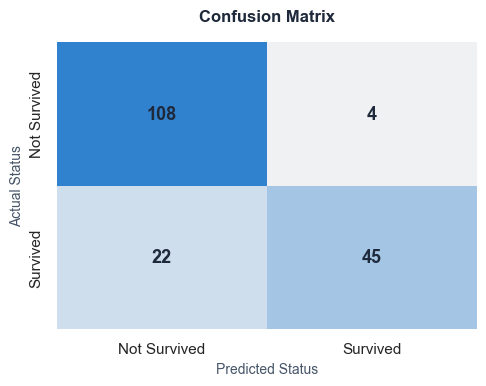

In [98]:
# 1. Mengukur akurasi pada data latih (Train Accuracy)
correct_train = sum(1 for i in range(len(X_train)) if dt_classifier.predict(X_train[i]) == y_train[i])
train_acc = correct_train / len(X_train)

# 2. Mengukur akurasi pada data uji (Test Accuracy)
correct_test = sum(1 for i in range(len(X_test)) if dt_classifier.predict(X_test[i]) == y_test[i])
test_acc = correct_test / len(X_test)

# 3. Print hasil akurasi
print(f"Train Accuracy: {train_acc * 100:.2f}%")
print(f"Test Accuracy : {test_acc * 100:.2f}%")

# Menghitung nilai Confusion Matrix 
TP, TN, FP, FN = 0, 0, 0, 0
for i in range(len(X_test)):
    pred = dt_classifier.predict(X_test[i])
    actual = y_test[i]
    if pred == 1 and actual == 1: 
        TP += 1
    elif pred == 0 and actual == 0: 
        TN += 1
    elif pred == 1 and actual == 0: 
        FP += 1
    elif pred == 0 and actual == 1: 
        FN += 1

# Memvisualisasikan Confusion Matrix menggunakan Seaborn Heatmap
plt.figure(figsize=(5, 4))
matrix_data = [[TN, FP], [FN, TP]]

cmap_cm = sns.light_palette("#3182ce", as_cmap=True)

sns.heatmap(matrix_data, annot=True, fmt="d", cmap=cmap_cm, 
            xticklabels=["Not Survived", "Survived"], 
            yticklabels=["Not Survived", "Survived"], 
            cbar=False, annot_kws={"size": 13, "weight": "bold", "color": "#1e293b"})

plt.title("Confusion Matrix", fontsize=12, fontweight="bold", pad=15, color="#1e293b")
plt.xlabel("Predicted Status", fontsize=10, color="#475569")
plt.ylabel("Actual Status", fontsize=10, color="#475569")
plt.tight_layout()
plt.show()

### 10. Feature Importance
Visualize the feature split frequencies.

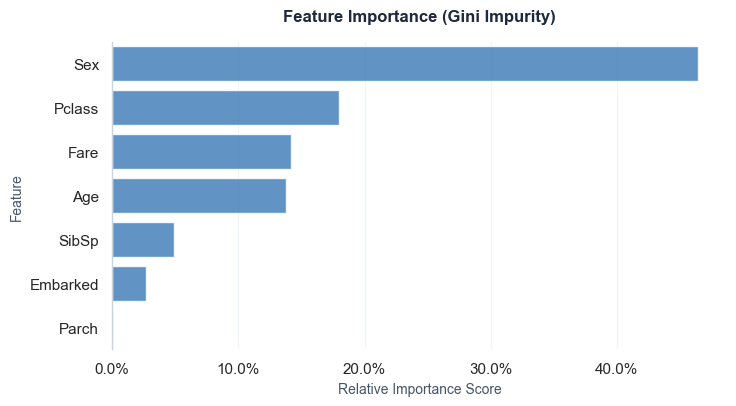

In [99]:
# 1. Mendapatkan nilai kepentingan fitur (Gini Importance) s
feature_importances = dt_classifier.get_feature_importances(feature_names)

# 2. Mengurutkan fitur dari tingkat pengaruh tertinggi
sorted_importances = sorted(feature_importances.items(), key=lambda x: x[1], reverse=True)
sorted_features = [x[0] for x in sorted_importances]
sorted_values = [x[1] for x in sorted_importances]

# 3. Plotting bar chart horizontal dengan warna tema tunggal yang bersih
plt.figure(figsize=(7.5, 4.2))
sns.barplot(x=sorted_values, y=sorted_features, color="#3182ce", alpha=0.85)

plt.title("Feature Importance (Gini Impurity)", fontsize=12, fontweight="bold", pad=15, color="#1e293b")
plt.xlabel("Relative Importance Score", fontsize=10, color="#475569")
plt.ylabel("Feature", fontsize=10, color="#475569")

import matplotlib.ticker as mtick
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

sns.despine(left=False, bottom=True)
plt.tight_layout()
plt.show()


### 11. Predict New Passenger Survival
Predict survival for a new custom passenger profile:
- Profile: [Pclass=1, Sex=Female (1), Age=25, SibSp=0, Parch=0, Fare=80, Embarked=C (1)]

In [100]:
# Definisi data penumpang baru
test_passenger = [1, 1, 25, 0, 0, 80, 1]
result = dt_classifier.predict(test_passenger)

print("=== PREDIKSI STATUS KESELAMATAN PENUMPANG ===")
if result == 1:
    print("Hasil: Selamat (Survived)")
else:
    print("Hasil: Tidak Selamat (Not Survived)")
print("===============================================")

=== PREDIKSI STATUS KESELAMATAN PENUMPANG ===
Hasil: Selamat (Survived)


### 12. Decision Boundary
Visualize the decision boundary on the Age vs Fare 2D feature space.

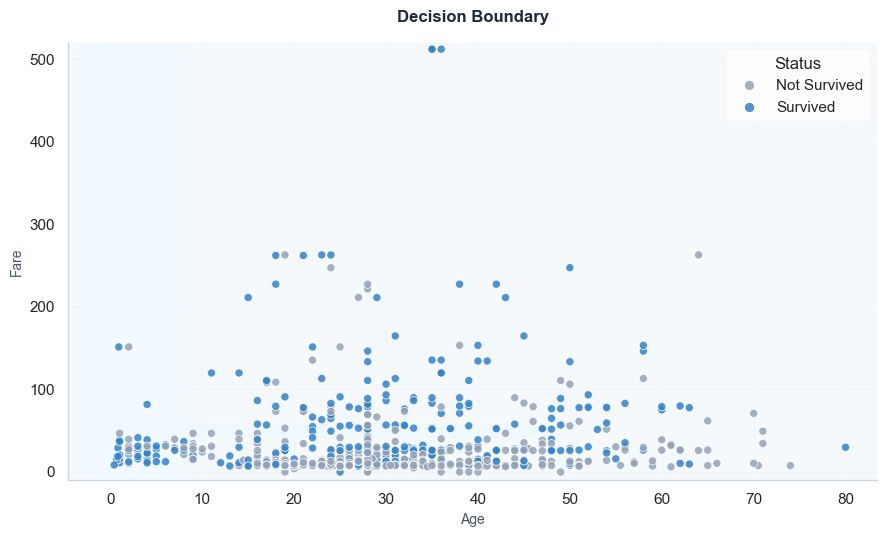

In [101]:
age_col = df["Age"]
fare_col = df["Fare"]

# Rentang min-max untuk sumbu X dan Y
x_min, x_max = age_col.min() - 5, age_col.max() + 5
y_min, y_max = fare_col.min() - 10, fare_col.max() + 10

# Membuat meshgrid untuk memetakan prediksi
xx, yy = np.meshgrid(np.arange(x_min, x_max, 2), np.arange(y_min, y_max, 10))

Z_pred = []
for i in range(len(xx)):
    row_preds = []
    for j in range(len(xx[i])):
        # Pengaturan sampel tetap untuk visualisasi 2D space
        sample = [3, 0, xx[i][j], 0, 0, yy[i][j], 0]
        row_preds.append(dt_classifier.predict(sample))
    Z_pred.append(row_preds)
Z_pred = np.array(Z_pred)

# Visualisasi Decision Boundary dengan Warna Tema Selaras
plt.figure(figsize=(9, 5.5))

# Colormap lembut untuk background contour
cmap_bg = ListedColormap(["#f1f5f9", "#ebf8ff"])
# Colormap untuk titik data
cmap_points = ListedColormap(["#94a3b8", "#3182ce"])

plt.contourf(xx, yy, Z_pred, alpha=0.6, cmap=cmap_bg)

# Plot sebaran data asli dengan white border pada marker agar bersih
scatter_plot = plt.scatter(df["Age"], df["Fare"], c=df["Survived"], cmap=cmap_points, edgecolor="w", linewidth=0.6, alpha=0.85, s=35)

plt.title("Decision Boundary", fontsize=12, fontweight="bold", pad=15, color="#1e293b")
plt.xlabel("Age", fontsize=10, color="#475569")
plt.ylabel("Fare", fontsize=10, color="#475569")
plt.legend(handles=scatter_plot.legend_elements()[0], labels=["Not Survived", "Survived"], title="Status", frameon=True, facecolor="white", edgecolor="none")
sns.despine()
plt.tight_layout()
plt.show()

### 13. Interactive Passenger Simulator
Input custom passenger features below using interactive widgets to simulate survival predictions in real-time.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML
import os
import base64

image_path = "titanic_ship.png"
if os.path.exists(image_path):
    with open(image_path, "rb") as image_file:
        encoded_image = base64.b64encode(image_file.read()).decode('utf-8')
        image_html = f'<img src="data:image/png;base64,{encoded_image}" style="width: 100%; height: 100%; border-radius: 12px; box-shadow: 0 8px 24px rgba(0,0,0,0.08); object-fit: cover; border: 1px solid #e2e8f0; display: block;" />'
else:
    image_html = """
    <div style="width: 100%; height: 100%; min-height: 320px; background-color: #f8fafc; border: 1.5px dashed #cbd5e1; border-radius: 12px; display: flex; flex-direction: column; align-items: center; justify-content: center; color: #94a3b8; font-family: sans-serif; overflow: hidden;">
        <span style="font-size: 40px; margin-bottom: 8px;">🚢</span>
        <span style="font-size: 13px; font-weight: 500;">Titanic Ship Image</span>
    </div>
    """

scoped_style = widgets.HTML("""
<style>
    .simulator-form-card {
        font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif !important;
        background: #ffffff !important;
        border: 1px solid #e2e8f0 !important;
        border-radius: 12px !important;
        box-shadow: 0 8px 24px rgba(0, 0, 0, 0.05) !important;
        padding: 24px !important;
        width: 100% !important;
        max-width: 100% !important; /* Mengikuti lebar kolom kiri sepenuhnya */
        box-sizing: border-box !important;
    }
    .simulator-form-title {
        font-size: 15px !important;
        font-weight: 700 !important;
        color: #0f172a !important;
        margin: 0 0 16px 0 !important;
        padding-bottom: 12px !important;
        border-bottom: 1px solid #e2e8f0 !important;
    }
    /* Styling label widget jupyter */
    .simulator-form-card .widget-label {
        font-weight: 600 !important;
        color: #475569 !important;
        font-size: 13px !important;
    }
    /* Styling dropdown select ala Bootstrap 5 */
    .simulator-form-card .widget-dropdown select {
        border-radius: 8px !important;
        border: 1px solid #cbd5e1 !important;
        padding: 4px 12px !important;
        background-color: #f8fafc !important;
        color: #1e293b !important;
        outline: none !important;
        font-size: 13px !important;
        transition: all 0.2s ease !important;
        height: 34px !important;
    }
    .simulator-form-card .widget-dropdown select:focus {
        border-color: #3b82f6 !important;
        box-shadow: 0 0 0 3px rgba(59, 130, 246, 0.15) !important;
        background-color: #ffffff !important;
    }
</style>
""")

# Menghitung Feature Importance secara dinamis
try:
    importances = dt_classifier.get_feature_importances(feature_names)
except NameError:
    temp_features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
    importances = dt_classifier.get_feature_importances(temp_features)

total_splits = sum(importances.values())
sorted_importances = sorted(importances.items(), key=lambda x: x[1], reverse=True)

importance_html_list = ""
for name, val in sorted_importances:
    pct = (val / total_splits * 100) if total_splits > 0 else 0.0
    importance_html_list += f"""
    <div style="display: flex; align-items: center; margin-bottom: 7px; font-size: 12px;">
        <span style="width: 70px; font-weight: 600; color: #475569;">{name}</span>
        <div style="flex-grow: 1; background-color: #f1f5f9; height: 6px; border-radius: 3px; overflow: hidden; margin: 0 8px;">
            <div style="background-color: #3b82f6; height: 100%; width: {pct}%; border-radius: 3px;"></div>
        </div>
        <span style="font-weight: 700; color: #2563eb; width: 40px; text-align: right;">{pct:.1f}%</span>
    </div>
    """

importance_compact_html = widgets.HTML(f"""
<div style="padding-left: 8px;">
    <h5 style="font-size: 13px; font-weight: 700; color: #0f172a; margin: 0 0 12px 0;">
        📊 Kolom Paling Berpengaruh (Model)
    </h5>
    <div>
        {importance_html_list}
    </div>
</div>
""")

# Define interactive widgets
half_width_layout = widgets.Layout(width='50%', margin='6px 0px')
full_width_layout = widgets.Layout(width='100%', margin='6px 0px')

pclass_w = widgets.Dropdown(options=[('1st Class', 1), ('2nd Class', 2), ('3rd Class', 3)], value=3, description='Pclass:', layout=half_width_layout)
sex_w = widgets.Dropdown(options=[('Male', 0), ('Female', 1)], value=0, description='Sex:', layout=half_width_layout)
sibsp_w = widgets.Dropdown(options=[('0', 0), ('1', 1), ('2', 2), ('3', 3), ('4', 4), ('5', 5), ('8', 8)], value=0, description='SibSp:', layout=half_width_layout)
class parch_w:
    pass
parch_w = widgets.Dropdown(options=[('0', 0), ('1', 1), ('2', 2), ('3', 3), ('4', 4), ('5', 5), ('6', 6)], value=0, description='Parch:', layout=half_width_layout)

age_w = widgets.IntSlider(value=25, min=0, max=80, step=1, description='Age:', layout=full_width_layout)
fare_w = widgets.FloatSlider(value=15.0, min=0.0, max=500.0, step=5.0, description='Fare ($):', layout=full_width_layout)
embarked_w = widgets.Dropdown(options=[('Southampton (S)', 0), ('Cherbourg (C)', 1), ('Queenstown (Q)', 2)], value=0, description='Embarked:', layout=full_width_layout)

for w in [pclass_w, sex_w, age_w, sibsp_w, parch_w, fare_w, embarked_w]:
    w.style = {'description_width': '80px'}

def predict_simulator(pclass, sex, age, sibsp, parch, fare, embarked):
    sample = [pclass, sex, age, sibsp, parch, fare, embarked]
    result = dt_classifier.predict(sample)
    accuracy_pct = test_acc * 100
     
    if result == 1:
        bg_color, border_color, text_color, status = "#ebf8ff", "#3182ce", "#2b6cb0", "Survived (Selamat)"
    else:
        bg_color, border_color, text_color, status = "#f1f5f9", "#94a3b8", "#475569", "Not Survived (Tidak Selamat)"
        
    html_output = f"""
    <div style="background-color: {bg_color}; color: {text_color}; padding: 16px; border-radius: 8px; border: 1.5px solid {border_color}; width: 100%; box-sizing: border-box; font-family: sans-serif; margin-top: 15px;">
        <h4 style="margin: 0 0 10px 0; font-size: 14px; text-transform: uppercase; letter-spacing: 0.5px;">🔮 Interactive Survival Prediction</h4>
        <p style="font-size: 16px; margin: 5px 0;">Status: <b style="text-decoration: underline;">{status}</b></p>
        <hr style="border: none; border-top: 1px solid {border_color}33; margin: 10px 0;">
        <p style="font-size: 11px; margin: 0; color: #64748b;">Model Accuracy (Test Set): <b>{accuracy_pct:.2f}%</b></p>
    </div>
    """
    display(HTML(html_output))

form_header = widgets.HTML("<h4 class='simulator-form-title'>🚢 Titanic Survival Simulator (Manual Decision Tree)</h4>")

left_column = widgets.VBox([
    widgets.HBox([pclass_w, sex_w], layout=widgets.Layout(width='100%')),
    age_w,
    fare_w,
    widgets.HBox([sibsp_w, parch_w], layout=widgets.Layout(width='100%')),
    embarked_w
], layout=widgets.Layout(width='58%'))

right_column = widgets.VBox([
    importance_compact_html
], layout=widgets.Layout(width='38%', margin='0px 0px 0px 4%'))

card_grid = widgets.HBox([
    left_column,
    right_column
], layout=widgets.Layout(width='100%', align_items='stretch'))

simulator_card = widgets.VBox([
    scoped_style,
    form_header,
    card_grid
])
simulator_card.add_class('simulator-form-card')

image_card_html = widgets.HTML(f"""
<div style="box-sizing: border-box; width: 100%; height: 100%; display: flex; flex-direction: column; overflow: hidden;">
    <div style="flex-grow: 1; min-height: 0; overflow: hidden; border-radius: 12px;">
        {image_html}
    </div>
    <div style="margin-top: 8px; font-family: sans-serif; font-size: 11px; color: #64748b; text-align: center; font-style: italic;">
        Majestic Titanic Cruise Ship Painting
    </div>
</div>
""", layout=widgets.Layout(width='100%', height='100%', overflow='hidden'))

image_card = widgets.Box([image_card_html], layout=widgets.Layout(width='40%', align_self='stretch', overflow='hidden'))

# 1. Inisialisasi output widget (prediction card) 
out = widgets.interactive_output(predict_simulator, {
    'pclass': pclass_w, 'sex': sex_w, 'age': age_w, 
    'sibsp': sibsp_w, 'parch': parch_w, 'fare': fare_w, 'embarked': embarked_w
})

left_side = widgets.VBox([
    simulator_card,
    out
], layout=widgets.Layout(width='58%'))

main_layout = widgets.HBox([
    left_side,
    image_card
], layout=widgets.Layout(width='100%', justify_content='space-between', align_items='stretch'))

display(main_layout)
